In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import os
print(os.getcwd())

C:\Users\Asus\Downloads\Eda project


In [5]:
df = pd.read_csv('ecommerce-eda/data.csv', encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
print("Shape of dataset:", df.shape)
print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])

Shape of dataset: (541909, 8)
Total Rows: 541909
Total Columns: 8


In [ ]:
df.info()


In [7]:
print("Missing Values in each column:")
print(df.isnull().sum())

Missing Values in each column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 5268


In [9]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [10]:
# Remove duplicate rows
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

After removing duplicates: (536641, 8)


In [11]:
# Drop rows where CustomerID is missing
df = df.dropna(subset=['CustomerID'])
print("After removing missing CustomerID:", df.shape)

After removing missing CustomerID: (401604, 8)


In [12]:
# Remove negative Quantity and UnitPrice
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
print("After removing negative values:", df.shape)

After removing negative values: (392692, 8)


In [13]:
# Convert InvoiceDate to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print("InvoiceDate dtype now:", df['InvoiceDate'].dtype)
print("Sample dates:")
print(df['InvoiceDate'].head())

InvoiceDate dtype now: datetime64[ns]
Sample dates:
0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]


In [14]:
# Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
print("TotalPrice column added!")
print(df[['Quantity', 'UnitPrice', 'TotalPrice']].head())

TotalPrice column added!
   Quantity  UnitPrice  TotalPrice
0         6       2.55       15.30
1         6       3.39       20.34
2         8       2.75       22.00
3         6       3.39       20.34
4         6       3.39       20.34


In [15]:
print("=== FINAL CLEANED DATA SUMMARY ===")
print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])
print("\nMissing Values:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)

=== FINAL CLEANED DATA SUMMARY ===
Total Rows: 392692
Total Columns: 9

Missing Values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
TotalPrice            float64
dtype: object


In [16]:
total_revenue = df['TotalPrice'].sum()
print("Total Revenue: £", round(total_revenue, 2))

Total Revenue: £ 8887208.89


In [17]:
print("=== KEY BUSINESS METRICS ===")
print("Total Orders:", df['InvoiceNo'].nunique())
print("Total Products:", df['StockCode'].nunique())
print("Total Customers:", df['CustomerID'].nunique())
print("Total Countries:", df['Country'].nunique())
print("Average Order Value: £", round(df.groupby('InvoiceNo')['TotalPrice'].sum().mean(), 2))

=== KEY BUSINESS METRICS ===
Total Orders: 18532
Total Products: 3665
Total Customers: 4338
Total Countries: 37
Average Order Value: £ 479.56


In [18]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print("=== TOP 10 BEST SELLING PRODUCTS ===")
print(top_products)

=== TOP 10 BEST SELLING PRODUCTS ===
Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


In [19]:
top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print("=== TOP 10 COUNTRIES BY REVENUE ===")
print(top_countries)

=== TOP 10 COUNTRIES BY REVENUE ===
Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64


In [20]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('Month')['TotalPrice'].sum().sort_index()
print("=== MONTHLY SALES TREND ===")
print(monthly_sales)

=== MONTHLY SALES TREND ===
Month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: TotalPrice, dtype: float64


In [21]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print("=== TOP 10 CUSTOMERS BY REVENUE ===")
print(top_customers)

=== TOP 10 CUSTOMERS BY REVENUE ===
CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: TotalPrice, dtype: float64


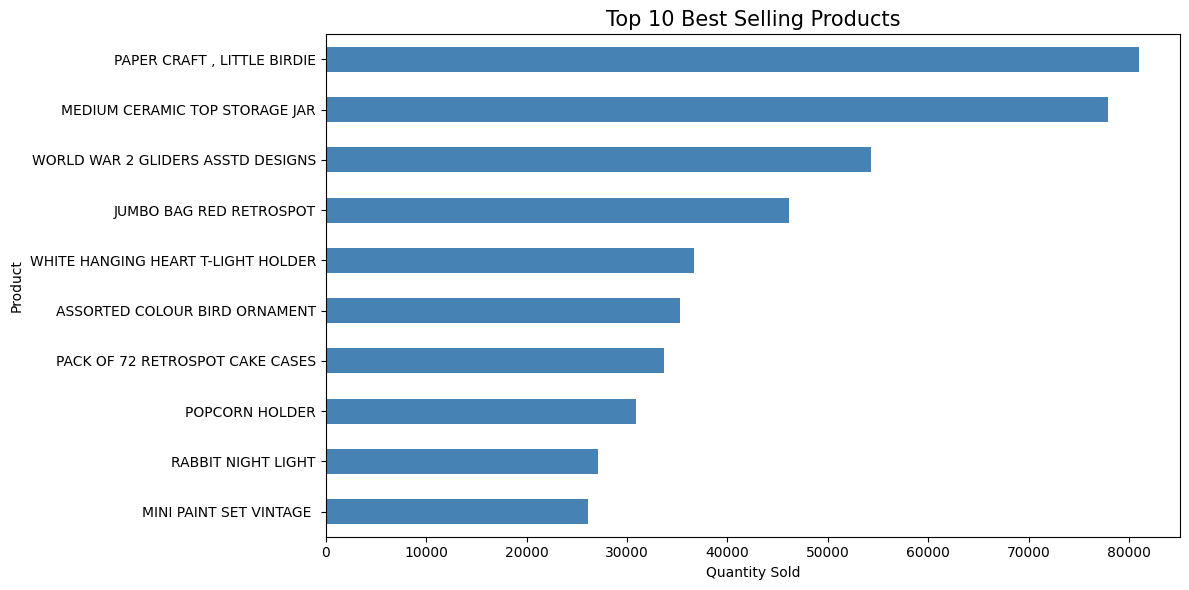

In [22]:
plt.figure(figsize=(12,6))
top_products.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Best Selling Products', fontsize=15)
plt.xlabel('Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.savefig('top_products.png')
plt.show()

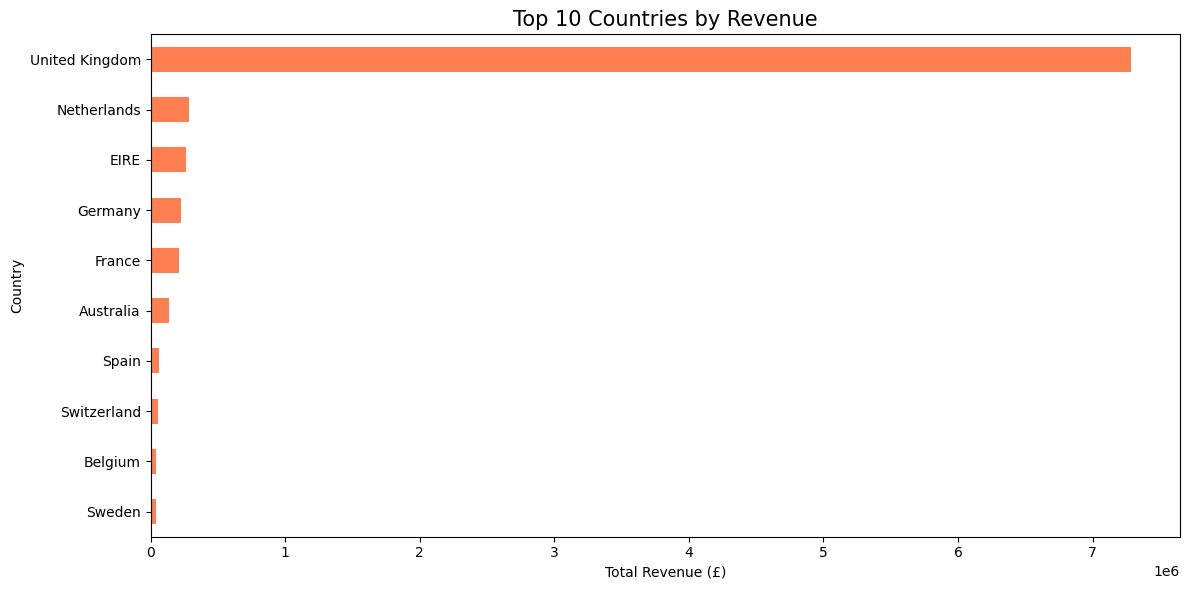

In [23]:
plt.figure(figsize=(12,6))
top_countries.sort_values().plot(kind='barh', color='coral')
plt.title('Top 10 Countries by Revenue', fontsize=15)
plt.xlabel('Total Revenue (£)')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('top_countries.png')
plt.show()

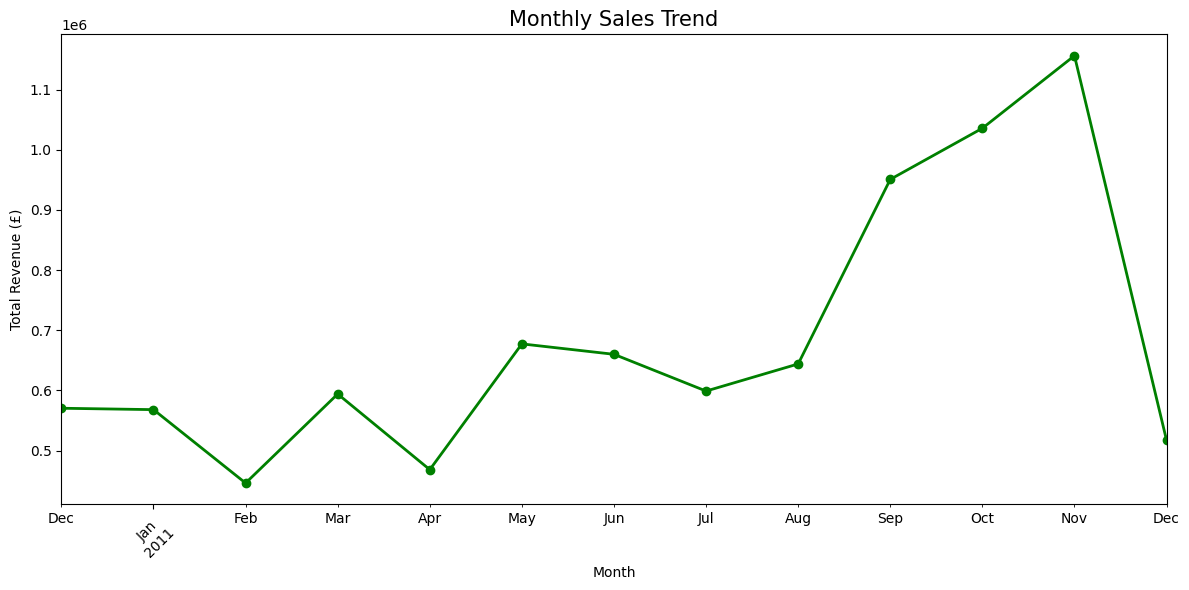

In [24]:
plt.figure(figsize=(12,6))
monthly_sales.plot(kind='line', color='green', marker='o', linewidth=2, markersize=6)
plt.title('Monthly Sales Trend', fontsize=15)
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_sales_trend.png')
plt.show()

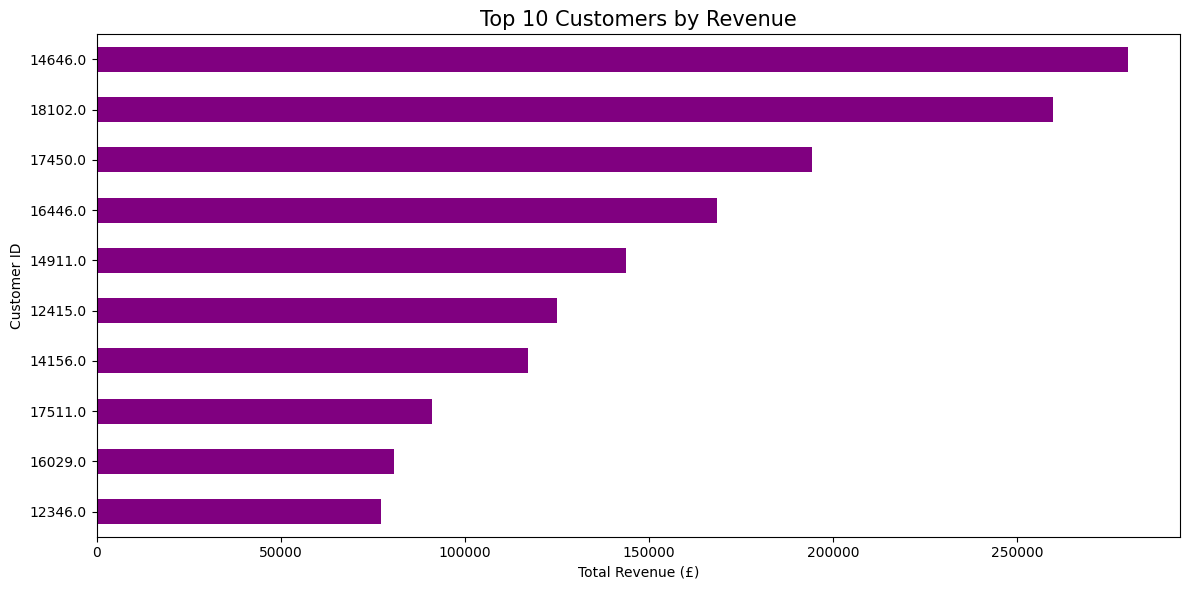

In [26]:
plt.figure(figsize=(12,6))
top_customers.sort_values().plot(kind='barh', color='purple')
plt.title('Top 10 Customers by Revenue', fontsize=15)
plt.xlabel('Total Revenue (£)')
plt.ylabel('Customer ID')
plt.tight_layout()
plt.savefig('top_customers.png')
plt.show()

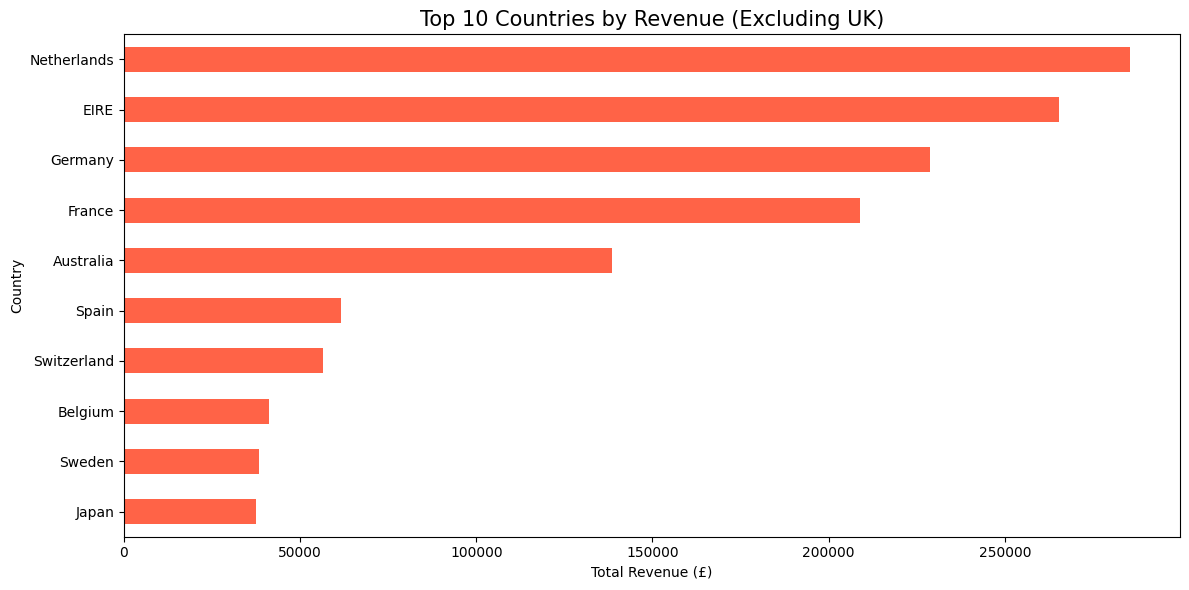

In [28]:
non_uk = df[df['Country'] != 'United Kingdom']
country_revenue = non_uk.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
country_revenue.sort_values().plot(kind='barh', color='tomato')
plt.title('Top 10 Countries by Revenue (Excluding UK)', fontsize=15)
plt.xlabel('Total Revenue (£)')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('top_countries_excl_uk.png')
plt.show()

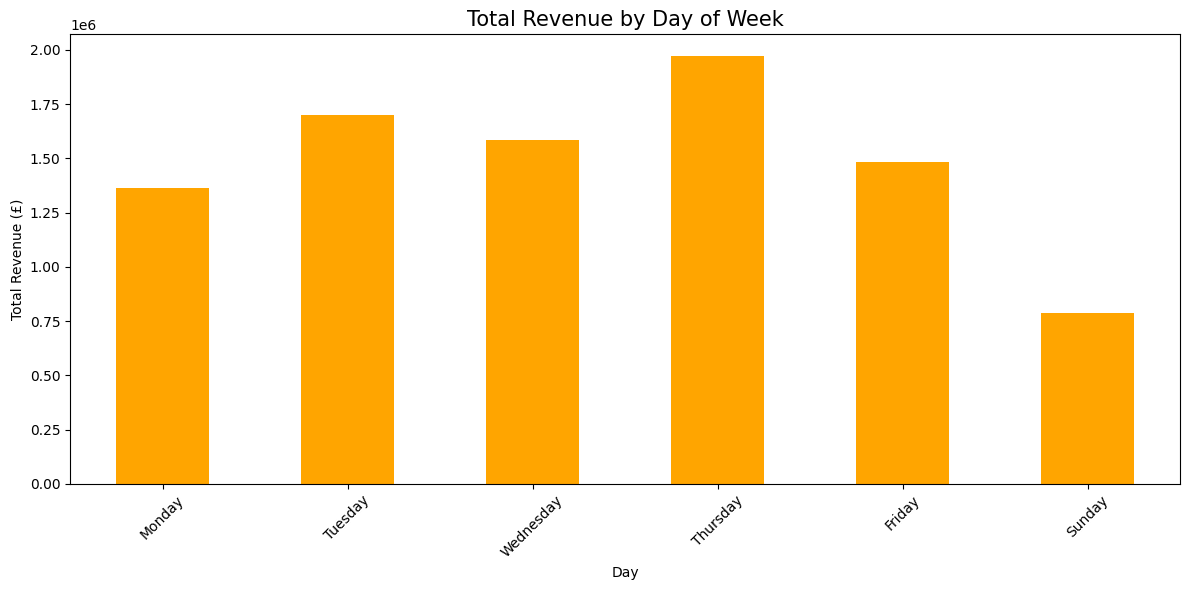

In [29]:
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
day_sales = df.groupby('DayOfWeek')['TotalPrice'].sum().reindex(day_order)

plt.figure(figsize=(12,6))
day_sales.plot(kind='bar', color='orange')
plt.title('Total Revenue by Day of Week', fontsize=15)
plt.xlabel('Day')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('sales_by_day.png')
plt.show()

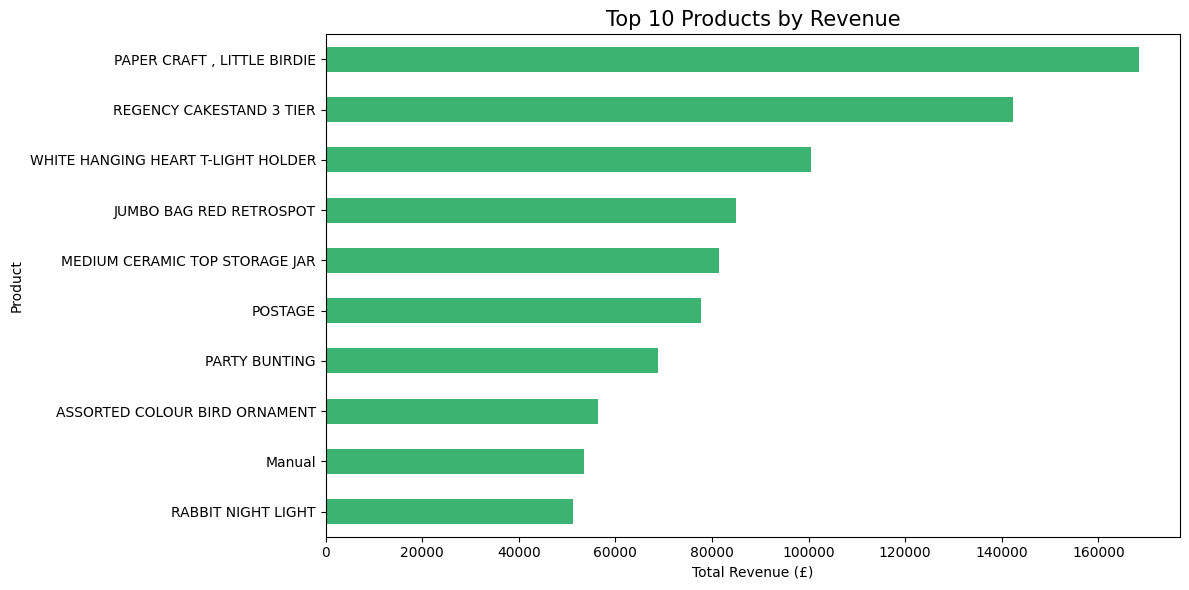

In [30]:
top_revenue_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_revenue_products.sort_values().plot(kind='barh', color='mediumseagreen')
plt.title('Top 10 Products by Revenue', fontsize=15)
plt.xlabel('Total Revenue (£)')
plt.ylabel('Product')
plt.tight_layout()
plt.savefig('top_products_revenue.png')
plt.show()

In [31]:
print("=" * 50)
print("   E-COMMERCE SALES ANALYSIS - KEY INSIGHTS")
print("=" * 50)

print("\n📊 BUSINESS OVERVIEW:")
print(f"Total Revenue: £{df['TotalPrice'].sum():,.2f}")
print(f"Total Orders: {df['InvoiceNo'].nunique():,}")
print(f"Total Customers: {df['CustomerID'].nunique():,}")
print(f"Total Countries: {df['Country'].nunique():,}")

print("\n🏆 TOP PERFORMING PRODUCT:")
print(df.groupby('Description')['Quantity'].sum().idxmax())

print("\n🌍 TOP PERFORMING COUNTRY:")
print(df.groupby('Country')['TotalPrice'].sum().idxmax())

print("\n📅 BEST SALES MONTH:")
print(df.groupby('Month')['TotalPrice'].sum().idxmax())

print("\n👑 TOP CUSTOMER ID:")
print(df.groupby('CustomerID')['TotalPrice'].sum().idxmax())

print("\n💡 KEY INSIGHTS:")
print("1. UK dominates with 82% of total revenue")
print("2. Sales peak in Nov 2011 - Christmas season")
print("3. Feb & Apr are the weakest months")
print("4. Top 10 customers contribute significantly")
print("5. Paper Craft Little Birdie is best seller")
print("=" * 50)

   E-COMMERCE SALES ANALYSIS - KEY INSIGHTS

📊 BUSINESS OVERVIEW:
Total Revenue: £8,887,208.89
Total Orders: 18,532
Total Customers: 4,338
Total Countries: 37

🏆 TOP PERFORMING PRODUCT:
PAPER CRAFT , LITTLE BIRDIE

🌍 TOP PERFORMING COUNTRY:
United Kingdom

📅 BEST SALES MONTH:
2011-11

👑 TOP CUSTOMER ID:
14646.0

💡 KEY INSIGHTS:
1. UK dominates with 82% of total revenue
2. Sales peak in Nov 2011 - Christmas season
3. Feb & Apr are the weakest months
4. Top 10 customers contribute significantly
5. Paper Craft Little Birdie is best seller
